In [1]:
# pratica do card 8
#a pagina Super Veloce da wikipedia pra baixar as fotos dos carros (ferrari 812 e lamborghini svj).
# tentei cobrir tudo que o video me  mostrou find, select, texto/link, tabela em dataframe,
# baixar imagem e um loop pegando o preco de varios livros da pagina inicial.

import requests
from bs4 import BeautifulSoup as bs
import pandas as pd
import re

In [2]:

r = requests.get("https://books.toscrape.com/")
webpage = bs(r.content)
print(webpage.prettify()[:500])   # imprimo só uma fatia pra não poluir a tela

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!-->
<html class="no-js" lang="en-us">
 <!--<![endif]-->
 <head>
  <title>
   All products | Books to Scrape - Sandbox
  </title>
  <meta content="text/html; charset=utf-8" http-equiv="content-type"/>
  <meta conte


In [3]:

primeiro_livro = webpage.find("article", attrs={"class": "product_pod"})

links_do_livro = [link['href'] for link in primeiro_livro.find_all("a")]
links_do_livro   # cada card tem 2 links um na imagem e outro no titulo

['catalogue/a-light-in-the-attic_1000/index.html',
 'catalogue/a-light-in-the-attic_1000/index.html']

In [4]:

sidebar = webpage.find("div", attrs={"class": "side_categories"})
links_generos = sidebar.find_all("a")

generos = []
for item in links_generos:
    nome = item.get_text().strip()   # tiro os espacos em branco do html
    url_genero = item.get('href')
    generos.append({"genero": nome, "link": url_genero})

for g in generos:
    print(f"[{g['genero']}] -> {g['link']}")

[Books] -> catalogue/category/books_1/index.html
[Travel] -> catalogue/category/books/travel_2/index.html
[Mystery] -> catalogue/category/books/mystery_3/index.html
[Historical Fiction] -> catalogue/category/books/historical-fiction_4/index.html
[Sequential Art] -> catalogue/category/books/sequential-art_5/index.html
[Classics] -> catalogue/category/books/classics_6/index.html
[Philosophy] -> catalogue/category/books/philosophy_7/index.html
[Romance] -> catalogue/category/books/romance_8/index.html
[Womens Fiction] -> catalogue/category/books/womens-fiction_9/index.html
[Fiction] -> catalogue/category/books/fiction_10/index.html
[Childrens] -> catalogue/category/books/childrens_11/index.html
[Religion] -> catalogue/category/books/religion_12/index.html
[Nonfiction] -> catalogue/category/books/nonfiction_13/index.html
[Music] -> catalogue/category/books/music_14/index.html
[Default] -> catalogue/category/books/default_15/index.html
[Science Fiction] -> catalogue/category/books/science-f

In [5]:

titulos = webpage.select("h3 a")

contador = 0
for t in titulos:
    if re.search(re.compile("the", re.IGNORECASE), t.get_text()):
        contador += 1

print(f"titulos com 'the': {contador} de {len(titulos)}")

titulos com 'the': 9 de 20


In [6]:

alerta = webpage.select_one("div.alert.alert-warning")
if alerta:
    print(alerta.get_text().strip())

Warning! This is a demo website for web scraping purposes. Prices and ratings here were randomly assigned and have no real meaning.


In [7]:

r2 = requests.get("https://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html")
livro = bs(r2.content)

tabela = livro.find("table", attrs={"class": "table table-striped"})   # acho a tabela product information
linhas = tabela.find_all("tr")

dados = {}
for linha in linhas:
    chave = linha.find("th").get_text().strip()
    valor = linha.find("td").get_text().strip()
    dados[chave] = valor

df = pd.DataFrame([dados])   # monto uma linha só com cada info numa coluna
df

,UPC,Product Type,Price (excl. tax),Price (incl. tax),Tax,Availability,Number of reviews
0,a897fe39b1053632,Books,£51.77,£51.77,£0.00,In stock (22 available),0


ferrari_812.jpg: 411151 bytes


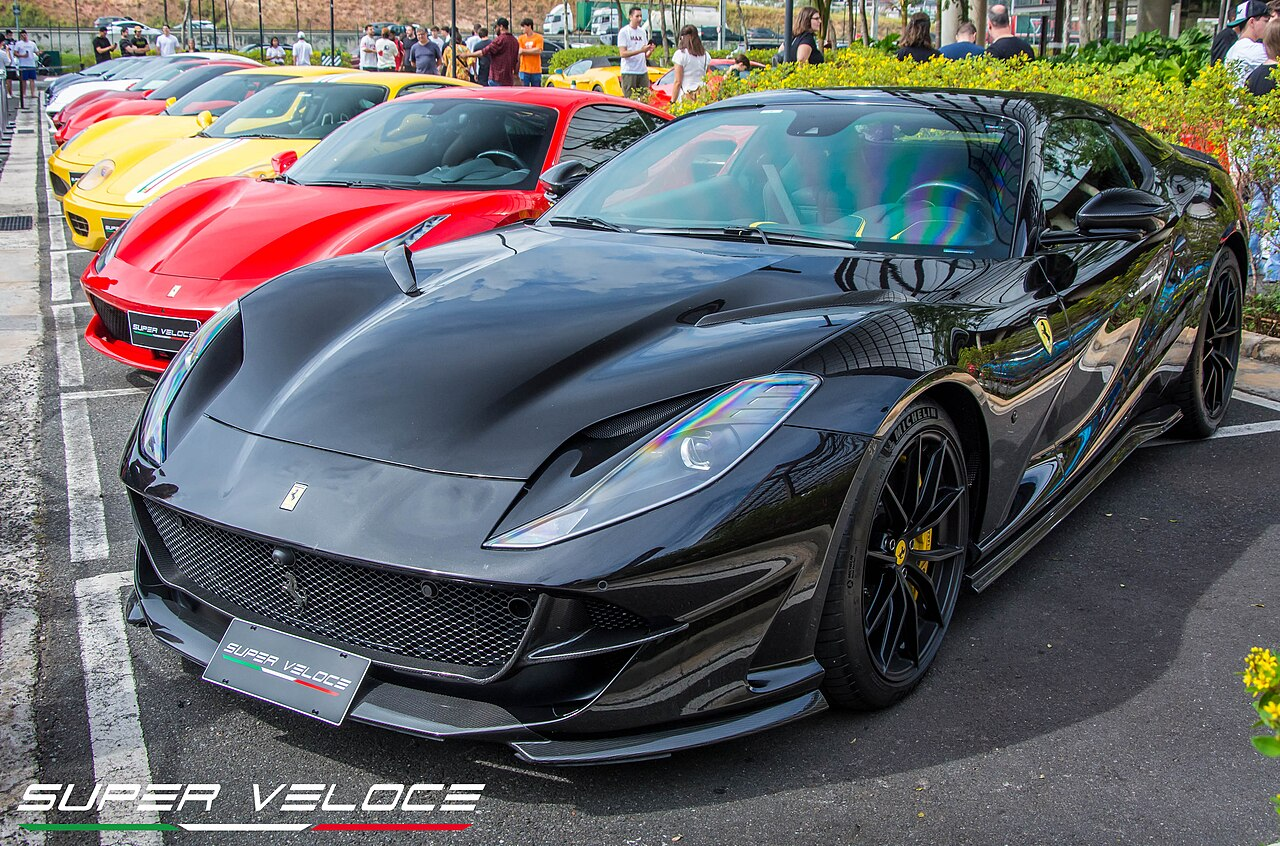

lamborghini_svj.jpg: 382199 bytes


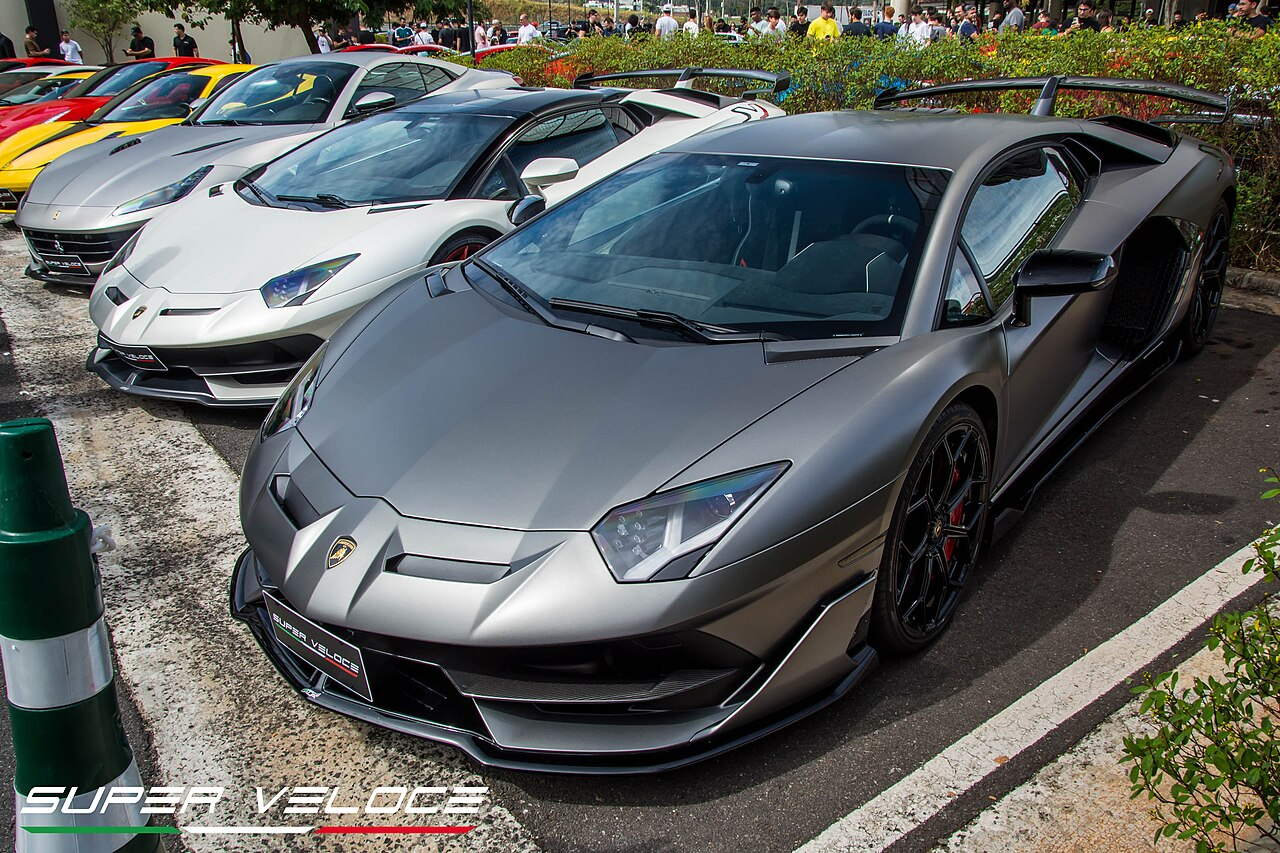

In [8]:
# troquei a capa do livro por carro pego a foto da 812 e da svj na wikipedia/ poderia ser qualquer site foi oque eu achei interessante e facil
from IPython.display import Image, display

# a wikipedia pede um user-agent dizendo quem ta fazendo a requisicao senao pode bloquear
headers = {"User-Agent": "card8-bootcamp-scraping/1.0 (projeto de estudo)"}

# as duas fotos estao na mesma pagina entao baixo o html uma vez so
r = requests.get("https://pt.wikipedia.org/wiki/Super_Veloce", headers=headers)
pagina_carros = bs(r.content)

# pra cada carro nome do arquivo e um pedaco da legenda que identifica a foto
carros = {
    "ferrari_812.jpg": "Ferrari 812",
    "lamborghini_svj.jpg": "Aventador SVJ",
}

for arquivo, legenda in carros.items():
    # acho a figura cuja tem  o nome do carro e pego a imagem de dentro dela
    imagem = pagina_carros.select_one(f"figure:has(figcaption:-soup-contains('{legenda}')) img")
    caminho_imagem = imagem['src']   # vem sem o https tipo //upload.wikimedia.org/...

    url_completa = "https:" + caminho_imagem.split("?")[0]              # completo o endereco
    url_completa = re.sub(r"/\d+px-", "/1280px-", url_completa)        # peco uma versao maior da foto

    img_data = requests.get(url_completa, headers=headers).content
    with open(arquivo, 'wb') as handler:
        handler.write(img_data)   # gravo a imagem na pasta local

    print(f"{arquivo}: {len(img_data)} bytes")
    display(Image(filename=arquivo, width=500))   # mostro a foto aqui no notebook

In [9]:

livros = webpage.select("article.product_pod")

precos = []
for livro_card in livros:
    titulo = livro_card.h3.a['title']   # pego o titulo completo que fica no atributo title e não no texto
    preco_texto = livro_card.select_one("p.price_color").get_text()
    precos.append({"titulo": titulo, "preco": preco_texto})

df_precos = pd.DataFrame(precos)
df_precos

,titulo,preco
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23
5,The Requiem Red,£22.65
6,The Dirty Little Secrets of Getting Your Dream...,£33.34
7,The Coming Woman: A Novel Based on the Life of...,£17.93
8,The Boys in the Boat: Nine Americans and Their...,£22.60
9,The Black Maria,£52.15
